In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm, LinearSegmentedColormap, SymLogNorm, ListedColormap, BoundaryNorm
from scipy.interpolate import interp1d, RegularGridInterpolator
from numpy.polynomial.legendre import leggauss
import sys
import os
import warnings
import h5py

helios_source = os.environ["HELIOS_PATH"] + "/source"
if helios_source not in sys.path:
    sys.path.append(helios_source)
from species_database import species_lib
import phys_const as pc
import quantities as quant

#drv.Context.pop()       # remove current context
#drv.Context.get_current().detach()  # fully destroy it

# get viridis colormap
cmap = plt.get_cmap('viridis')
cmap.set_bad(color='black')
# set dpi to 200
mpl.rcParams['figure.dpi'] = 200

In [2]:
### From HELIOS ###

def read_opac_file(quant, name, type="premixed", read_grid_parameters=False):
    """ reads the opacity table file for an individual species """

    with h5py.File(name, "r") as opac_file:

        print("\nReading opacity file:", name)

        try:
            opac_k = [k for k in opac_file["kpoints"][:]]
        except KeyError:
            opac_k = [k for k in opac_file["opacities"][:]]

        if type == "premixed":
            # Rayleigh scattering cross-sections
            quant.opac_scat_cross = [c for c in opac_file["weighted Rayleigh cross-sections"][:]]

            # pre-tabulated mean molecular mass values (& convert from mu to mean mass)
            quant.opac_meanmass = [m * pc.AMU for m in opac_file["meanmolmass"][:]]

        if type == "premixed" or read_grid_parameters is True:

            # wavelength grid
            try:
                quant.opac_wave = [x for x in opac_file["center wavelengths"][:]]
            except KeyError:
                quant.opac_wave = [x for x in opac_file["wavelengths"][:]]
            quant.nbin = np.int32(len(quant.opac_wave))

            # Gaussian y-points
            try:
                quant.gauss_y = [y for y in opac_file["ypoints"][:]]
            except KeyError:
                quant.gauss_y = [0]
            quant.ny = np.int32(len(quant.gauss_y))

            # interface positions of the wavelength bins
            try:
                quant.opac_interwave = [i for i in opac_file["interface wavelengths"][:]]
            except KeyError:
                # quick and dirty way to get the lamda interface values
                quant.opac_interwave = []
                quant.opac_interwave.append(quant.opac_wave[0] - (quant.opac_wave[1] - quant.opac_wave[0]) / 2)
                for x in range(len(quant.opac_wave) - 1):
                    quant.opac_interwave.append((quant.opac_wave[x + 1] + quant.opac_wave[x]) / 2)
                quant.opac_interwave.append(quant.opac_wave[-1] + (quant.opac_wave[-1] - quant.opac_wave[-2]) / 2)

            # widths of the wavelength bins
            try:
                quant.opac_deltawave = [w for w in opac_file["wavelength width of bins"][:]]
            except KeyError:
                quant.opac_deltawave = []
                for x in range(len(quant.opac_interwave) - 1):
                    quant.opac_deltawave.append(quant.opac_interwave[x + 1] - quant.opac_interwave[x])

            # temperature grid
            quant.ktemp = [t for t in opac_file["temperatures"][:]]
            quant.ntemp = np.int32(len(quant.ktemp))

            # pressure grid
            quant.kpress = [p for p in opac_file["pressures"][:]]
            quant.npress = np.int32(len(quant.kpress))

    return opac_k


def calc_planck(lamda, temp):
    """ calculates the Planckian blackbody function at a given wavelength and temperature """

    term1 = 2 * pc.H * pc.C**2 / lamda**5

    term2 = np.exp(pc.H * pc.C / (lamda * pc.K_B * temp)) - 1

    result = term1 * 1 / term2

    return result


def interpolate_opac(quant, T, P, log=False, logP=False):
    # T in K, P in bar
    # Convert P to dyn/cm^2 to match quant.kpress
    if logP:
        P = np.log10(P*1e6)
    else:
        P = P*1e6

    # Create interpolator for each wavelength and y-point combination
    opac_k = np.array(quant.opac_k).reshape(quant.ntemp, quant.npress, quant.nbin, quant.ny)
    
    # If log interpolation requested, convert to log space
    if log:
        opac_k = np.log10(opac_k)
    
    # Create points for temperature and pressure only
    if logP:
        points = (quant.ktemp, np.log10(quant.kpress))
    else:
        points = (quant.ktemp, quant.kpress)
    
    result = np.zeros((quant.nbin, quant.ny))
    
    # Interpolate each wavelength and y-point combination separately
    for i in range(quant.nbin):
        for j in range(quant.ny):
            values = opac_k[:,:,i,j]
            interpolator = RegularGridInterpolator(points, values, bounds_error=False, fill_value=None)
            result[i,j] = interpolator([[T, P]])[0]
    
    # If log interpolation was used, convert back to linear space
    if log:
        result = 10**result
    
    return result

In [3]:
# psat from GGchem
mmHg = 1.3328e+03 # dyn/cm^2
bar = 1.0e+06 # dyn/cm^2

def p_sat(T, species, mask=True):
    
    if species == 'H2':
        # NIST (21-32K)
        psat = 10.0**(3.54314 - 99.395/(T + 7.726))*bar
        if mask:
            mask = (T < 21.0) | (T > 32.0)
            psat[mask] = np.nan
        return psat

    elif species == 'He':
        psat = np.empty_like(T)
        psat.fill(np.nan)  # He does not have a saturation pressure in the range
        return psat
         
    elif species == 'N2':
        # NIST (63-126K)
        psat = 10.0**(3.7362 - 264.651/(T - 6.788))*bar
        if mask:
            mask = (T < 63.0) | (T > 126.0)
            psat[mask] = np.nan
        return psat

    elif species == 'CH4':
        # only solid
        # NIST (90-190K) and GGchem
        # Prydz, R.; Goodwin, R.D., J. Chem. Thermodyn., 1972, 4,1 
        psat = 10.0**(3.9895 - 443.028/(T-0.49))*bar
        if mask:
            mask = (T < 90.0) | (T > 190.0)
            psat[mask] = np.nan
        return psat
    
    elif species == 'CO2':
        # Yaws' Chemical Properties Handbook (McGraw-Hill 1999) (216-305K), GGchem
        C = np.array([35.0187E+00, -1.5119E+03, -1.1335E+01, 9.3383E-03, 7.7626E-10])
        psat = C[0] + C[1] / T + C[2] * np.log10(T) + C[3] * T + C[4] * T**2
        psat = 10**psat * mmHg
        if mask:
            mask = (T < 216.0) | (T > 305.0)
            psat[mask] = np.nan
        return psat

    elif species == 'H2O':
        
            # Ackerman & Marley 2001 (liquid!), GGchem
            # TC = T - 273.15
            # psat_l = 6112.1*np.exp((18.729*TC - TC**2/227.3)/(TC + 257.87))
            # Yaws' Chemical Properties Handbook (McGraw-Hill 1999) (273-647K)
            C = np.array([29.8605e+00, -3.1522e+03, -7.3037e+00, 2.4247e-09, 1.8090e-06])
            psat = C[0] + C[1] / T + C[2] * np.log10(T) + C[3] * T + C[4] * T**2
            psat = 10**psat * mmHg
            psat_final = psat.copy()
    
            # Ackerman & Marley 2001 (solid), GGchem
            TC   = np.minimum(2000.0,T)-273.15 # T[degree Celsius]
            psat = 6111.5*np.exp((23.036*TC - TC**2/333.7)/(TC + 279.82))
            psat_final[T<273.16] = psat[T<273.16]

            # Haldemann+ 2020
            #psat = 0.05 + 2.95 * (T/1000 - 1)/39 # GPa
            #psat = psat * 1e+10 # dyn/cm^2
            #psat_final[T>647.0] = psat[T>647.0]

            if mask:
                mask = T > 647.0
                psat_final[mask] = np.nan

            return psat_final
    
    elif species == 'NH3':
        # CRC Handbook of Chemistry and Physics (Weast 1971), GGchem
        psat = np.exp(10.53 - 2161.0/T - 86596.0/T**2)*bar
        if mask:
            mask = T > mols['NH3']['critical'][0]  # 405.5 K
            psat[mask] = np.nan

        # NIST (164-371.5K)
        # psat = 10.0**(3.18757 - 506.713/(T - 80.78))*bar
        # psat[T>239.6] = 10**(4.86886 - 1113.928/(T[T>239.6] - 10.409))*bar
        # if mask:
        #     mask = (T < 164.0) | (T > 371.5)
        #     psat[mask] = np.nan
        
        return psat
    
    elif species == 'CO':
        # Yaws' Chemical Properties Handbook (McGraw-Hill 1999) (68-132K), GGchem
        C = np.array([51.8145E+00, -7.8824E+02, -2.2734E+01, 5.1225E-02, 4.6603E-11])
        psat = C[0] + C[1] / T + C[2] * np.log10(T) + C[3] * T + C[4] * T**2
        psat = 10**psat * mmHg
        if mask:
            mask = (T < 68.0) | (T > 132.0)
            psat[mask] = np.nan
        return psat

In [20]:
cia_pairs = np.array(["CH4-CH4", "CO2-CH4", "CO2-CO2", "CO2-H2", "H2-CH4", "H2-He", "N2-CH4", "N2-H2", "N2-H2O", "N2-N2", "H2-H2"]) #etc
cia_pair = cia_pairs[3]
print(cia_pair)

abs_species = np.array(['CH4', 'CO2', 'H2O'])

opacity_folder = os.environ["HELIOS_PATH"] + '/input/opacity/r50_kdistr/'
files = []
for species in cia_pair.split('-'):
    if species in abs_species:
        files.append(f"{species}_opac_ip_kdistr.h5")
files = np.unique(files).tolist()

cia_pair_split = cia_pair.split('-')
for compair in cia_pairs:
    compair = compair.split('-')
    if (compair[0] in cia_pair_split) and (compair[1] in cia_pair_split):
        files.append(f"CIA_{compair[0]}{compair[1]}_opac_ip_kdistr.h5")

len_tail = len("_opac_ip_kdistr.h5")

mu = np.mean([species_lib[sp].weight for sp in cia_pair_split]) * pc.AMU
if cia_pair_split[0] == cia_pair_split[1]:
    mr = 1.0
else:
    mr = 0.5

quant_with = quant.Store()
quant_without = quant.Store()
quant_without_any = quant.Store()

# Read in example files for general parameters
quant_with.opac_k = np.array(read_opac_file(quant_with, opacity_folder + 'CO2_opac_ip_kdistr.h5', type='other', read_grid_parameters=True))
quant_with.opac_k[:] = 0.0
quant_without.opac_k = np.array(read_opac_file(quant_without, opacity_folder + 'CO2_opac_ip_kdistr.h5', type='other', read_grid_parameters=True))
quant_without.opac_k[:] = 0.0
quant_without_any.opac_k = np.array(read_opac_file(quant_without_any, opacity_folder + 'CO2_opac_ip_kdistr.h5', type='other', read_grid_parameters=True))
quant_without_any.opac_k[:] = 0.0

for file in files:
    print(file)
    new_opac_k = np.array(read_opac_file(quant_with, opacity_folder + file, type='other', read_grid_parameters=False))
    factor = species_lib[file[:-len_tail]].weight * pc.AMU / mu * mr # kappa_tot = sum(x_i * mu_i/mu * kappa_i)
    if file.split('_')[1] == cia_pair.replace('-', ''):
        print('1', file)
        factor *= mr # kappa ~ x_i^2 for CIA
        quant_with.opac_k += new_opac_k * factor
    elif file[:3] == 'CIA':
        print('2', file)
        factor *= mr # kappa ~ x_i^2 for CIA
        quant_with.opac_k += new_opac_k * factor
        quant_without.opac_k += new_opac_k * factor
    else:
        print('3', file)
        quant_with.opac_k += new_opac_k * factor    
        quant_without.opac_k += new_opac_k * factor
        quant_without_any.opac_k += new_opac_k * factor

quants = [quant_with, quant_without, quant_without_any]

min_opacs = np.minimum(quants[0].opac_k, quants[1].opac_k)
min_opacs = np.minimum(min_opacs, quants[2].opac_k)
min_opacs = np.maximum(min_opacs, 1e-15)

for q in quants:
    min_mask = q.opac_k <= 1e-10
    q.opac_k[min_mask] = min_opacs[min_mask]

for q in quants:
    q.opac_k = q.opac_k.reshape(q.ntemp, q.npress, q.nbin, q.ny)
    q.gauss_weight = leggauss(q.ny)[1]
    q.opac_band_lay = np.sum(0.5 * q.gauss_weight * q.opac_k, axis=-1)

CO2-H2

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CO2_opac_ip_kdistr.h5

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CO2_opac_ip_kdistr.h5

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CO2_opac_ip_kdistr.h5
CO2_opac_ip_kdistr.h5

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CO2_opac_ip_kdistr.h5
3 CO2_opac_ip_kdistr.h5
CIA_CO2CO2_opac_ip_kdistr.h5

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CIA_CO2CO2_opac_ip_kdistr.h5
2 CIA_CO2CO2_opac_ip_kdistr.h5
CIA_CO2H2_opac_ip_kdistr.h5

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CIA_CO2H2_opac_ip_kdistr.h5
1 CIA_CO2H2_opac_ip_kdistr.h5
CIA_H2H2_opac_ip_kdistr.h5

Reading opacity file: /home/moon/ddahlb/PhD/HELIOS/input/opacity/r50_kdistr/CIA_H2H2_opac_ip_kdistr.h5
2 CIA_H2H2_opac_ip_kdistr.h5


In [21]:
# constants in cgs
h = 6.62607015e-27  # erg s
c = 2.99792458e10   # cm/s
kB = 1.380649e-16  # erg/K

def expand_wave(interwave, gauss_y):
    x = (gauss_y[None, :] - 0.5) * 2
    dwave = (interwave[1:] - interwave[:-1])[:, None]
    mean_wave = (interwave[1:] + interwave[:-1])[:, None] / 2
    x = 0.5 * dwave * x + mean_wave
    return x

def dB_dT(lam, T):
    D = 2 * h**2 * c**3 / (lam**6 * kB * T**2)
    num = np.exp(h * c / (lam * kB * T))
    denom = (np.exp(h * c / (lam * kB * T)) - 1)**2
    return D * (num / denom)

dtau = []

for i, q in enumerate(quants):
    q.opac_interwave = np.array(q.opac_interwave)
    q.opac_deltawave = np.array(q.opac_deltawave)
    q.gauss_y = np.array(q.gauss_y)
    q.ktemp = np.array(q.ktemp)
    q.kpress = np.array(q.kpress)

    expanded_wave = expand_wave(q.opac_interwave, q.gauss_y)
    dBdT = dB_dT(expanded_wave[None, None, :], q.ktemp[:, None, None, None])
    
    integrated_dB_dT = np.sum(0.5 * q.opac_deltawave[None, None, :, None] * q.gauss_weight[None, None, None, :] * dBdT, axis=-1)
    num_ross = np.sum(integrated_dB_dT, axis=-1)
    
    #denom_ross = np.sum(integrated_dB_dT / q.opac_band_lay, axis=-1)
    denom_ross = np.sum(0.5 * q.opac_deltawave[None, None, :, None] * q.gauss_weight[None, None, None, :] * dBdT / q.opac_k, axis=(-1, -2))
    q.ross_opac_T_pl = num_ross / denom_ross

    density = mu * q.kpress[None, :] / (kB * q.ktemp[:, None])
    dtau.append(q.ross_opac_T_pl * density)

/tmp/ipykernel_21868/2571987844.py:15: RuntimeWarning: overflow encountered in exp
  num = np.exp(h * c / (lam * kB * T))
/tmp/ipykernel_21868/2571987844.py:16: RuntimeWarning: overflow encountered in exp
  denom = (np.exp(h * c / (lam * kB * T)) - 1)**2
/tmp/ipykernel_21868/2571987844.py:16: RuntimeWarning: overflow encountered in square
  denom = (np.exp(h * c / (lam * kB * T)) - 1)**2
/tmp/ipykernel_21868/2571987844.py:17: RuntimeWarning: invalid value encountered in divide
  return D * (num / denom)


12
[4.         9.33333333]


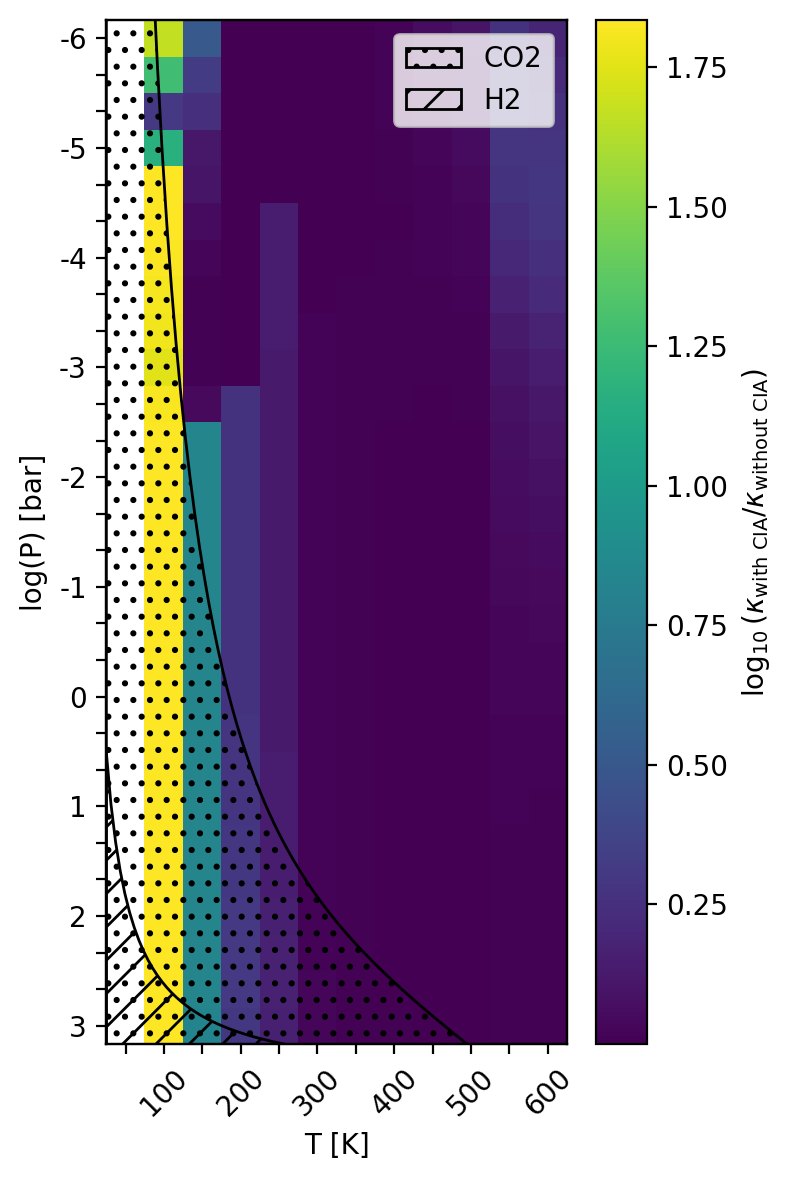

In [22]:
# plot rosseland mean (dev_ross_opac_T_pl) dep. on P, T

logP_plot = np.log10(np.array(quants[0].kpress)*1e-6) # convert from dyn/cm^2 to bar
T_plot = np.array(quants[0].ktemp)

Tmax = 600
i_Tmax = np.where(T_plot > Tmax)[0][0]
T_plot = T_plot[:i_Tmax]

rosseland_plot = quants[0].ross_opac_T_pl[:i_Tmax,:] / quants[1].ross_opac_T_pl[:i_Tmax,:]
#rosseland_plot = quants[0].ross_opac_T_pl[:i_Tmax,:]
rosseland_plot = np.log10(rosseland_plot)
#print(np.nanmin(rosseland_plot), np.nanmean(rosseland_plot), np.nanmax(rosseland_plot))
#print(np.prod(rosseland_plot.shape),  np.sum(np.isnan(rosseland_plot)), np.sum(np.isinf(rosseland_plot)))
if (np.isnan(rosseland_plot)+np.isinf(rosseland_plot)).sum() == np.prod(rosseland_plot.shape):
    print('all nan')
    rosseland_plot[np.isinf(rosseland_plot)] = 1.0
    

fig, ax = plt.subplots(figsize=(4, 6))
im = plt.imshow(rosseland_plot.T[::-1,:], origin='lower', aspect='auto', vmax=None)
cbar = plt.colorbar(im)
#cbar.set_label(r'$\log_{10}(d\tau [cm^{-1}])$')
cbar.set_label(r'$\log_{10}(\kappa_{\text{with CIA}} / \kappa_{\text{without CIA}})$')

ax2 = ax.twinx()
ax.set_ylim(ax.get_ylim()) # reset, otherwise they change (?)
Ts = np.linspace(25, Tmax+25, 100)
T_plots = (Ts-Ts.min())/(Ts.max()-Ts.min()) * (i_Tmax) - .5
#print(T_plots)
hatches = ['..', '//']
for i_species, species in enumerate(cia_pair.split('-')):
    p_sats = np.log10(p_sat(Ts, species, mask=False)*1e-6)
    ax2.fill_between(T_plots, p_sats, 4, label=species, hatch=hatches[i_species], color='none', edgecolor='black')
ax2.set_xlim(-0.5, i_Tmax-0.5)	
ax2.set_ylim(3+0.5/3, -(6+0.5/3))
ax2.set_yticks([])
ax2.legend()

print(i_Tmax)
ax.set_xticks(np.arange(len(T_plot)))
ax.set_xticklabels([f"{v:.0f}" if (i+1) % 2 == 0 else " " for i,v in enumerate(T_plot)], rotation=45)
ax.set_xlabel('T [K]')

ax.set_yticks(np.arange(len(logP_plot)))
ax.set_yticklabels([f"{v:.1g}" if f"{v:.1f}"[-1] == "0" else " " for v in logP_plot[::-1]])
ax.set_ylabel('log(P) [bar]')

#ax.set_title(f'{cia_pair} Rosseland mean ratio', loc='left')
plt.tight_layout()

fig.savefig(f'images/CIAreport/{cia_pair}_rosseland_mean_ratio.png', dpi=300)

print(np.array(rosseland_plot.shape)/3)

In [23]:
m_earth = 5.972e27 # g
r_earth = 6.371e8 # cm

def scale_height(T, mu, M_P=m_earth, R_P=r_earth):
    g = pc.G * M_P / R_P**2
    return kB * T / (mu * g)

1.5548937728381526e-16 105861.83894895458 21239365.76497508
0.0 0.3036619415026831 1.0
12


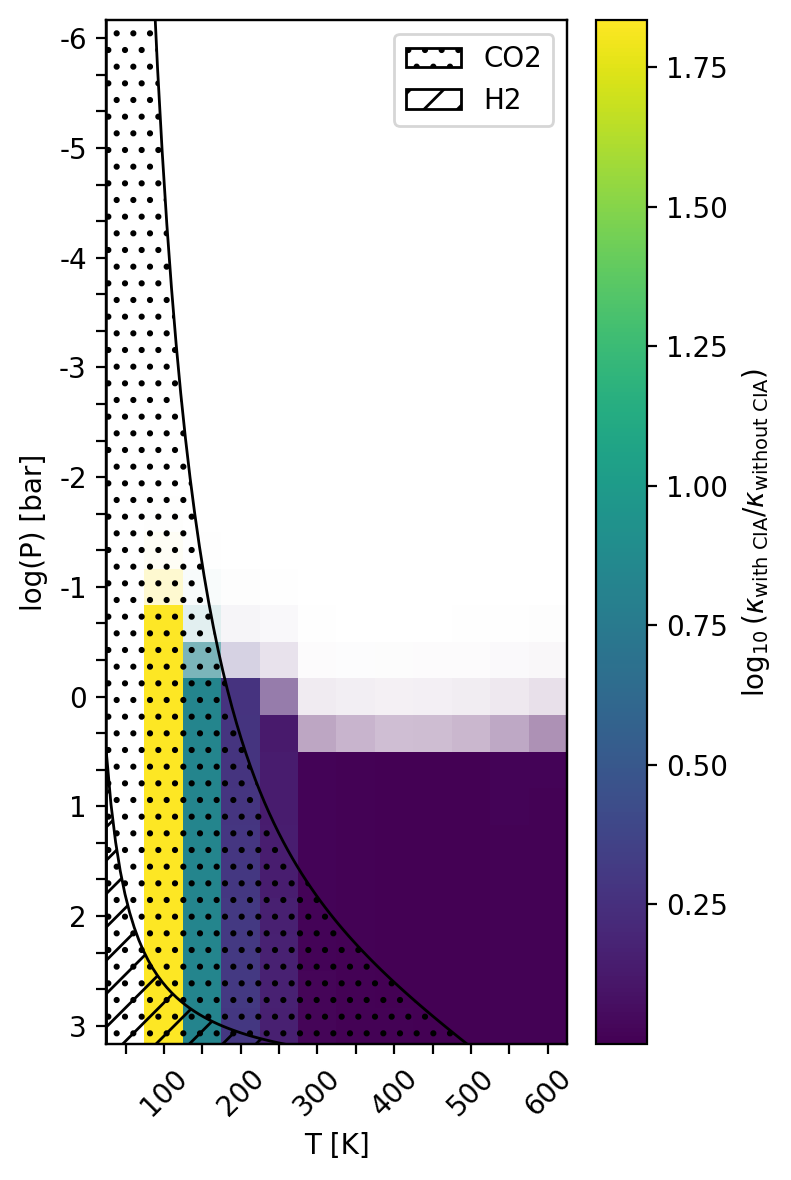

In [24]:
# consider the optical depth (alpha = min(tau, 1))

h_scale = scale_height(T_plot, mu)
tau_plot = dtau[0][:i_Tmax,:] * h_scale[:, None]
print(np.nanmin(tau_plot), np.nanmean(tau_plot), np.nanmax(tau_plot))
alpha = np.minimum(tau_plot, 1)
alpha[np.isnan(alpha)] = 0
#alpha = np.maximum(alpha, 5e-1)
print(np.min(alpha), np.mean(alpha), np.max(alpha))

rosseland_plot = quants[0].ross_opac_T_pl[:i_Tmax,:] / quants[1].ross_opac_T_pl[:i_Tmax,:]
rosseland_plot = np.log10(rosseland_plot)
#print(np.nanmin(rosseland_plot), np.nanmean(rosseland_plot), np.nanmax(rosseland_plot))
#print(np.prod(rosseland_plot.shape),  np.sum(np.isnan(rosseland_plot)), np.sum(np.isinf(rosseland_plot)))

fig, ax = plt.subplots(figsize=(4, 6))
im = plt.imshow(rosseland_plot.T[::-1,:], alpha=alpha.T[::-1,:], origin='lower', aspect='auto')
cbar = plt.colorbar(im)
#cbar.set_label(r'$\log_{10}(d\tau [cm^{-1}])$')
cbar.set_label(r'$\log_{10}(\kappa_{\text{with CIA}} / \kappa_{\text{without CIA}})$')

ax2 = ax.twinx()
ax.set_ylim(ax.get_ylim()) # reset, otherwise they change (?)
Ts = np.linspace(25, Tmax+25, 100)
T_plots = (Ts-Ts.min())/(Ts.max()-Ts.min()) * (i_Tmax) - .5
#print(T_plots)
hatches = ['..', '//']
for i_species, species in enumerate(cia_pair.split('-')):
    p_sats = np.log10(p_sat(Ts, species, mask=False)*1e-6)
    ax2.fill_between(T_plots, p_sats, 4, label=species, hatch=hatches[i_species], color='none', edgecolor='black')
ax2.set_xlim(-0.5, i_Tmax-0.5)	
ax2.set_ylim(3+0.5/3, -(6+0.5/3))
ax2.set_yticks([])
ax2.legend()

print(i_Tmax)
ax.set_xticks(np.arange(len(T_plot)))
ax.set_xticklabels([f"{v:.0f}" if (i+1) % 2 == 0 else " " for i,v in enumerate(T_plot)], rotation=45)
ax.set_xlabel('T [K]')

ax.set_yticks(np.arange(len(logP_plot)))
ax.set_yticklabels([f"{v:.1g}" if f"{v:.1f}"[-1] == "0" else " " for v in logP_plot[::-1]])
ax.set_ylabel('log(P) [bar]')

#ax.set_title(f'{cia_pair} Rosseland mean ratio', loc='left')
plt.tight_layout()

fig.savefig(f'images/CIAreport/{cia_pair}_rosseland_mean_ratio_alpha.png', dpi=300)

In [10]:
i_T = 1
i_P = 3*4

print(quants[0].ktemp[i_T:i_T+2])
print(quants[0].kpress[i_P]*1e-6, 'bar')
print(quants[0].ross_opac_T_pl[i_T:i_T+2,i_P])

[100 150]
0.01 bar
[1.67726719e-09 1.42393989e-07]


## Diagnostics

1e-06 bar


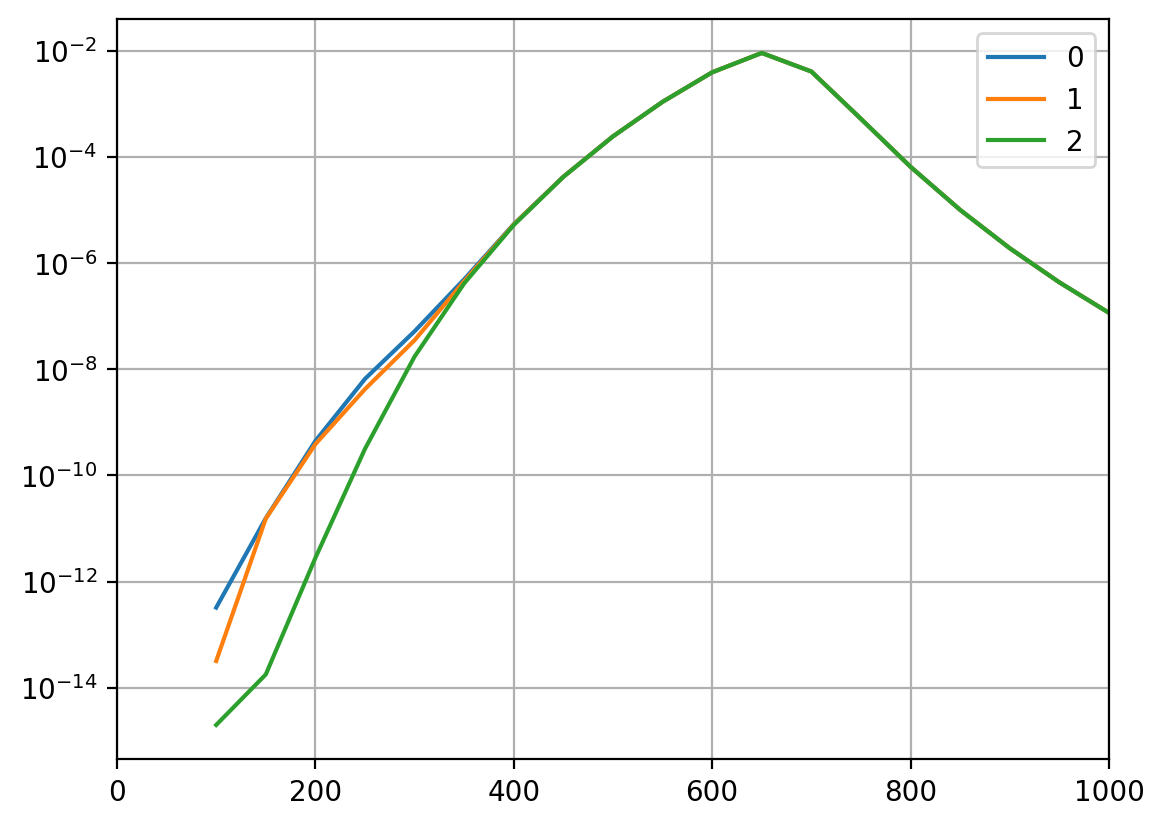

In [11]:
iP = 3*0
print(quants[0].kpress[iP]*1e-6, 'bar')

for i,q in enumerate(quants[:]):
    plt.plot(q.ktemp, q.ross_opac_T_pl[:,iP], label=i)

#plt.plot(quants[0].ktemp, quants[0].ross_opac_T_pl[:,-1]/quants[1].ross_opac_T_pl[:,-1], label='ratio')
#plt.plot(quants[0].ktemp, quants[0].ross_opac_T_pl[:,-1]-quants[1].ross_opac_T_pl[:,-1], label='diff')

plt.yscale('log')
plt.xlim(0,1e3)
plt.legend()
plt.grid()

100


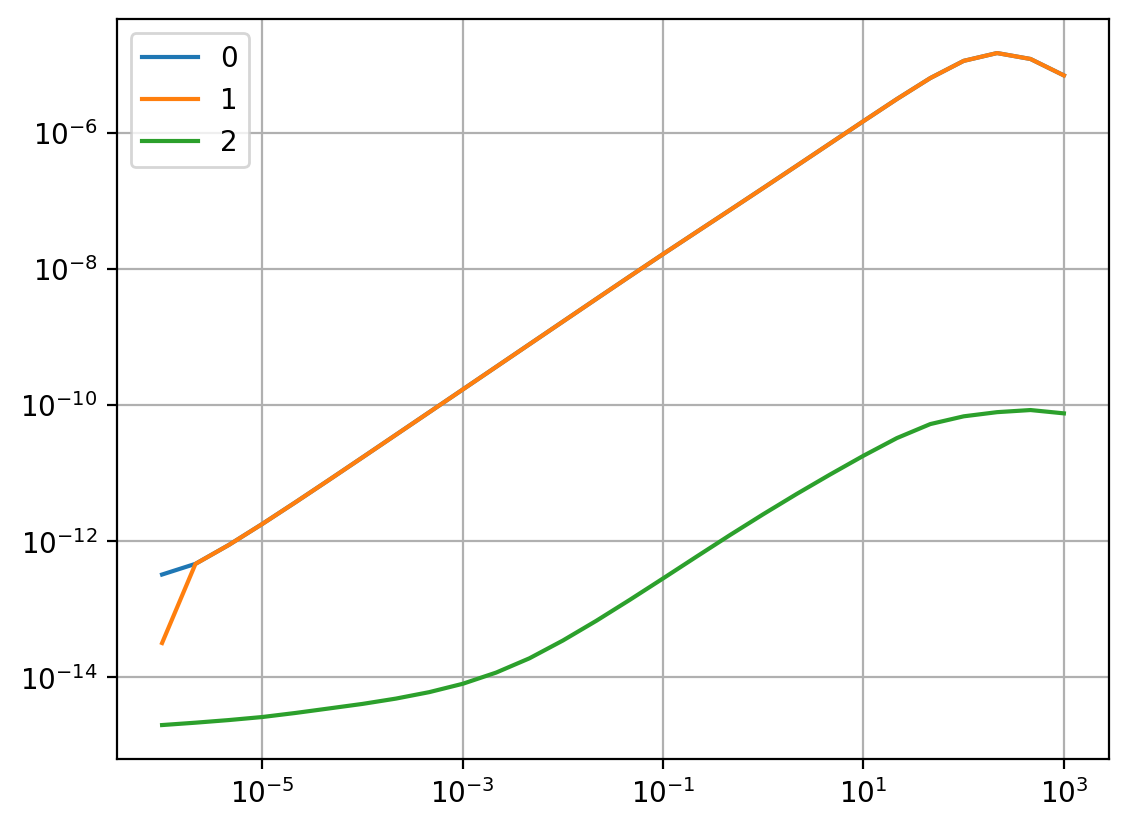

In [12]:
iT = 1
print(quants[0].ktemp[iT])

for i,q in enumerate(quants[:]):
    plt.plot(q.kpress*1e-6, q.ross_opac_T_pl[iT,:], label=i)

#plt.plot(quants[0].ktemp, quants[0].ross_opac_T_pl[:,-1]/quants[1].ross_opac_T_pl[:,-1], label='ratio')
#plt.plot(quants[0].ktemp, quants[0].ross_opac_T_pl[:,-1]-quants[1].ross_opac_T_pl[:,-1], label='diff')

plt.xscale('log')
plt.yscale('log')
plt.xlim(None,None)
plt.legend()
plt.grid()

100
2.154434673495986e-06


/tmp/ipykernel_21868/2571987844.py:16: RuntimeWarning: overflow encountered in square
  denom = (np.exp(h * c / (lam * kB * T)) - 1)**2


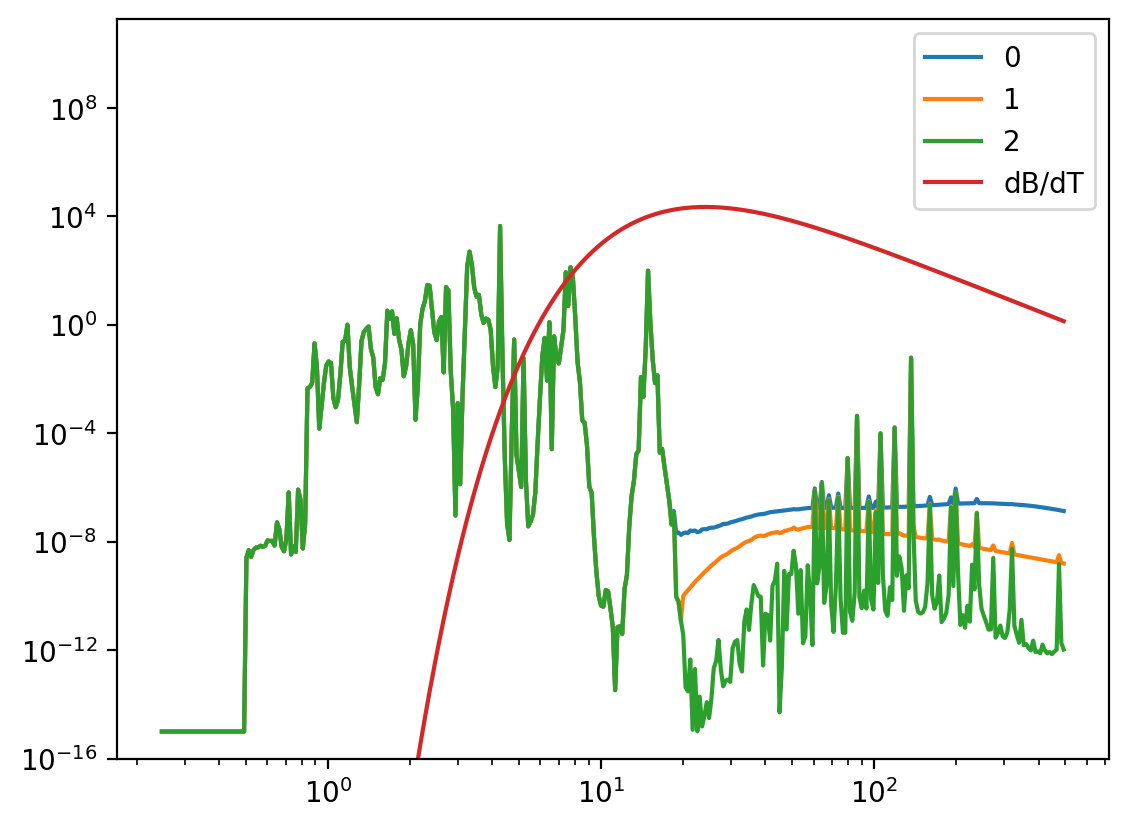

In [19]:
iT = 1
iP = 1 #3*0
print(quants[0].ktemp[iT])
print(quants[0].kpress[iP]*1e-6)

for i,q in enumerate(quants[:]):
    plt.plot(np.array(q.opac_wave)*1e4, q.opac_band_lay[iT,iP,:], label=i)

plt.plot(np.array(quants[0].opac_wave)*1e4, dB_dT(np.array(quants[0].opac_wave), quants[0].ktemp[iT]), label='dB/dT')

plt.xscale('log')
plt.yscale('log')
#plt.xlim(0.3, 50)
plt.ylim(1e-16, None)
plt.legend()

500


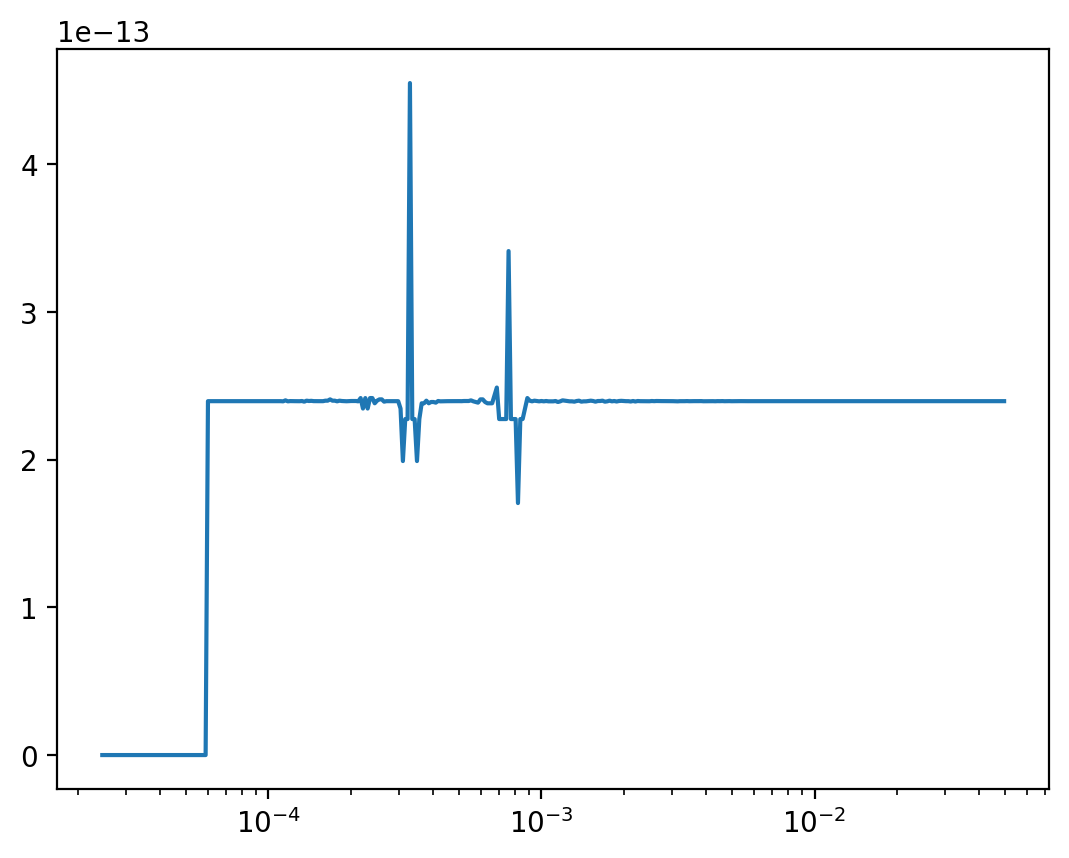

In [15]:
iT = 9
print(quants[0].ktemp[iT])

plt.plot(quants[0].opac_wave, quants[0].opac_band_lay[iT,-1,:]-quants[1].opac_band_lay[iT,-1,:])

#plt.plot(quants[0].opac_wave, dB_dT(np.array(quants[0].opac_wave), quants[0].ktemp[iT]), label='T')

plt.xscale('log')
#plt.yscale('log')
#plt.ylim(0.9, 1.1)

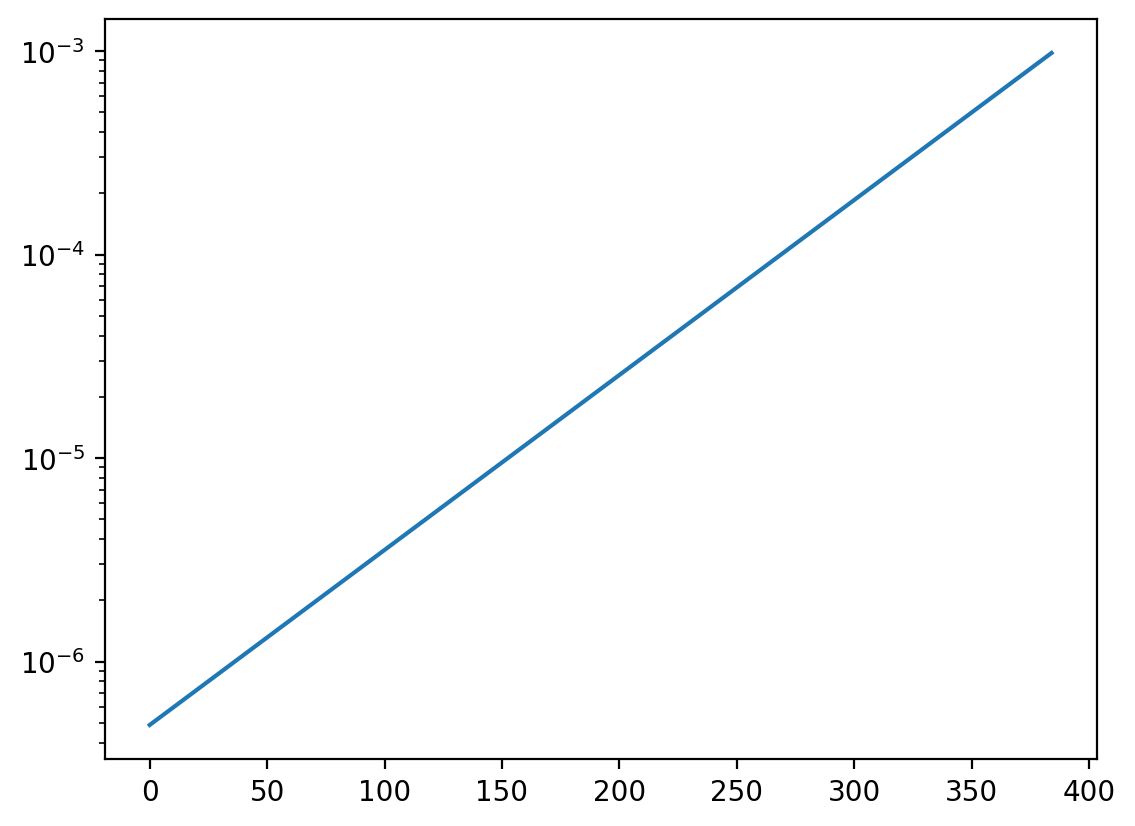

In [16]:
plt.plot(quants[0].opac_deltawave)
plt.yscale('log')

In [17]:
print(1/(44*pc.AMU))

1.3686683550184368e+22
